#**Detecting the anomalous activity of a ship’s engine**

This project develops a robust anomaly detection system for a company’s shipping fleet. Engine faults can lead to operational downtime, safety risks, delayed deliveries, and ultimately reduced profitability. By analysing sensor data collected from ship engines, this project applies statistical techniques and feature engineering to identify unusual behaviour that may indicate early‑stage faults.

## **Business context**

Early detection enables timely maintenance, reduces unplanned breakdowns, and improves both operational efficiency and customer satisfaction

You are provided with a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). As you work through this project, keep in mind that, typically speaking, anomalies would make up a minority of the data points (i.e., about 1% to 5% of the data points would be anomalies).

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

Your task is to develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. Therefore, you’ll explore the data and:
- employ preprocessing and feature engineering
- perform anomaly detection.

<br></br>

> **Disclaimer**
>
> Please note that although a real-life data set was provided, the business context in this project is fictitious. Any resemblance to companies and persons (living or dead) is coincidental. The course designers and hosts assume no responsibility or liability for any errors or omissions in the content of the business context and data sets. The information in the data sets is provided on an 'as is' basis with no guarantees of completeness, accuracy, usefulness, or timeliness.

<br></br>

## **Objective**
- explore the data set
- preprocess the data and conduct feature engineering
- apply statistical techniques to detect anomalies
- use ML algorithms to detect anomalies.



#Initial Data Evaluation

In [ ]:
# Importing the required libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [ ]:
# Importing the data set with the provided URL.

url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

# Read the csv file from GitHub into a new dataframe.

df_engine = pd.read_csv(url)

# Display the shape of the dataframe and view the head.

print(df_engine.shape)
df_engine.head()




(19535, 6)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


From the information above, we can see that our dataset has 19535 rows and 6 columns.

In [ ]:
# View the DataFrame information
df_engine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB


The columns contain numeric data with no null values.

In [ ]:
# Identify cells with missing values within the dataframe
df_engine.isnull().sum()


,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0


In [ ]:
# identify rows with duplicate values within the DataFrame.

df_engine.duplicated().sum()

np.int64(0)

There are no cells with missing values or duplicate values within our dataset.

In [ ]:
# Generate the descriptive statistics of the data showing the 95th percentile

df_engine.describe(percentiles=[0.25,0.75,0.95])


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
95%,1324.000000,5.058040,12.208475,4.438415,84.940778,88.612891
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


The descriptive statistics shows information about the individual features within the dataset. We can see the mean value, minimum and maximum values for each column. The table above also shows the 95th percentile by using the percentiles argument.

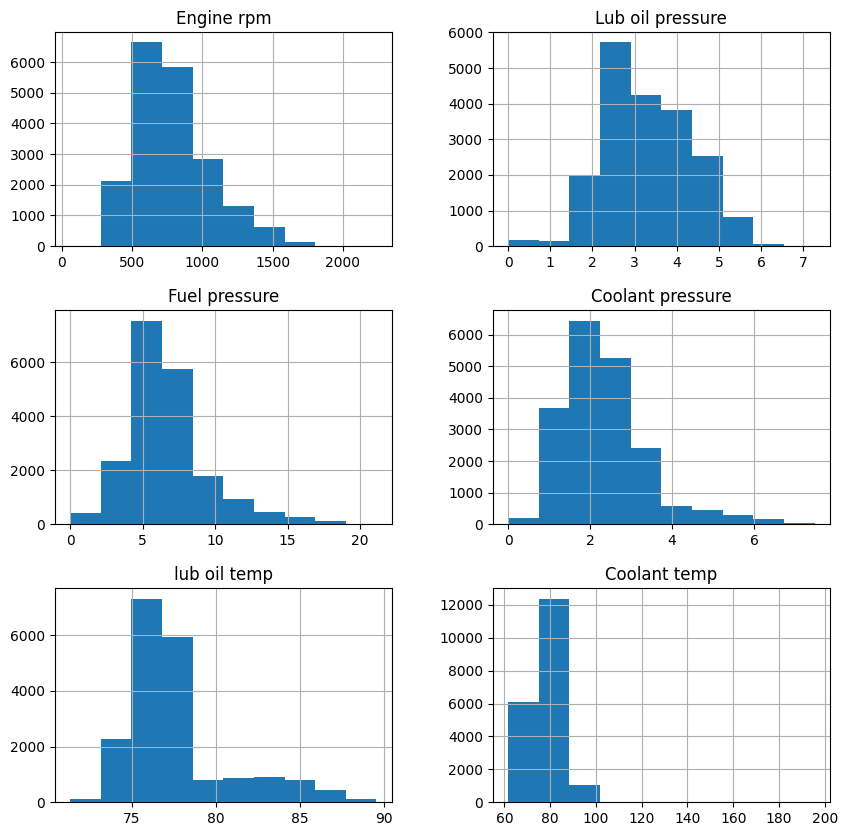

In [ ]:
# create 6 hist plots for each of the 6 features

df_engine.hist(figsize=(10,10))
plt.show()

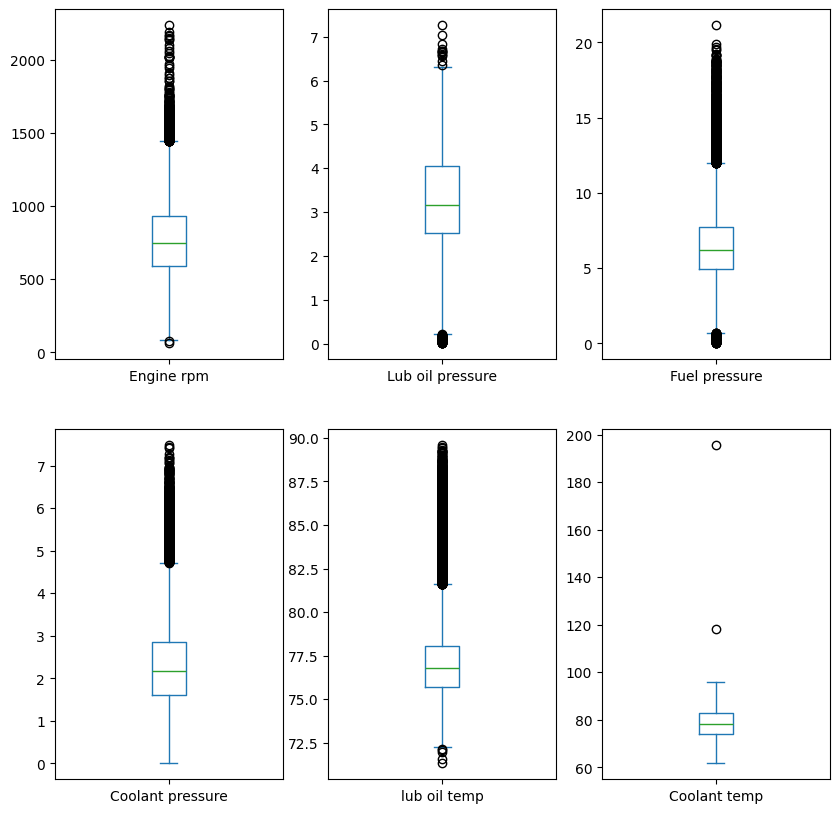

In [ ]:
# create 6 boxplots for each of the 6 features
# the visual plots help to see presence of outliers.

df_engine.plot(kind='box', subplots=True, layout=(2,3), figsize=(10,10))
plt.show()

#Anomaly detection using a statistical method - IQR method

In [ ]:
# Use the interquartile range (IQR) method to identify outliers for each feature.
# calculate IQR for each feature
Q1 = df_engine.quantile(0.25)
Q3 = df_engine.quantile(0.75)

# compute and view the IQR
IQR = Q3 - Q1
print(IQR)


Engine rpm          341.000000
Lub oil pressure      1.536457
Fuel pressure         2.828087
Coolant pressure      1.248374
lub oil temp          2.345700
Coolant temp          9.019990
dtype: float64


In [ ]:
# Create a new binary column for each feature indicating outliers
original_columns = df_engine.columns[:6] # Select only the original feature columns
for column in original_columns:
  lower_bound = Q1[column] - 1.5 * IQR[column]
  upper_bound = Q3[column] + 1.5 * IQR[column]
  df_engine[f'{column}_outlier_iqr'] = ((df_engine[column] < lower_bound) | (df_engine[column] > upper_bound)).astype(int)

# Display the first few rows with the new outlier columns
display(df_engine.head(10))

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier_iqr,Lub oil pressure_outlier_iqr,Fuel pressure_outlier_iqr,Coolant pressure_outlier_iqr,lub oil temp_outlier_iqr,Coolant temp_outlier_iqr
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0
5,589,2.933888,6.358464,2.461478,77.534616,75.403745,0,0,0,0,0,0
6,885,2.034509,15.499680,1.522790,78.959645,80.817985,0,0,1,0,0,0
7,576,5.495972,13.114658,1.251058,78.091390,71.934674,0,0,1,0,0,0
8,535,3.159440,8.676361,1.265139,82.408722,80.752747,0,0,0,0,1,0
9,806,3.946885,21.138326,1.572569,74.923316,72.112692,0,0,1,0,0,0


In [ ]:
# Create a new column to sum the binary outlier columns for each row
outlier_columns = [col for col in df_engine.columns if col.endswith('_outlier_iqr')]
df_engine['total_outliers_iqr'] = df_engine[outlier_columns].sum(axis=1)

# Display the first few rows with the new total outliers column
display(df_engine.head())

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier_iqr,Lub oil pressure_outlier_iqr,Fuel pressure_outlier_iqr,Coolant pressure_outlier_iqr,lub oil temp_outlier_iqr,Coolant temp_outlier_iqr,total_outliers_iqr
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0


In [ ]:
# Filter the dataframe to show rows with 1 or more outliers - at least one feature
iqr_anomalies1 = df_engine[df_engine['total_outliers_iqr'] >= 1]

# Display the first few rows of the anomalies and their shape
display(iqr_anomalies1.head())
print(iqr_anomalies1.shape)

# percentage anomalies
percentage_outliers = (iqr_anomalies1.shape[0] / df_engine.shape[0]) * 100
print("These represent", percentage_outliers, "% of the total rows")





,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier_iqr,Lub oil pressure_outlier_iqr,Fuel pressure_outlier_iqr,Coolant pressure_outlier_iqr,lub oil temp_outlier_iqr,Coolant temp_outlier_iqr,total_outliers_iqr
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1
6,885,2.034509,15.499680,1.522790,78.959645,80.817985,0,0,1,0,0,0,1
7,576,5.495972,13.114658,1.251058,78.091390,71.934674,0,0,1,0,0,0,1
8,535,3.159440,8.676361,1.265139,82.408722,80.752747,0,0,0,0,1,0,1


(4636, 13)
These represent 23.73176350140773 % of the total rows


In [ ]:
# Filter the DataFrame to show rows with 2 or more outliers
iqr_anomalies2 = df_engine[df_engine['total_outliers_iqr'] >= 2]

# Display the first few rows of the anomalies and their shape
display(iqr_anomalies2.head(10))
print(iqr_anomalies2.shape)

# percentage anomalies
percentage_outliers = (iqr_anomalies2.shape[0] / df_engine.shape[0]) * 100
print("These represent", percentage_outliers, "% of the total rows")

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier_iqr,Lub oil pressure_outlier_iqr,Fuel pressure_outlier_iqr,Coolant pressure_outlier_iqr,lub oil temp_outlier_iqr,Coolant temp_outlier_iqr,total_outliers_iqr
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,1,0,0,0,1,0,2
122,1454,2.063374,6.168260,1.260121,83.372256,82.718247,1,0,0,0,1,0,2
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,0,0,1,0,1,0,2
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,1,0,0,0,1,0,2
148,1494,2.443220,3.548139,1.953403,82.234541,83.953914,1,0,0,0,1,0,2
157,534,5.922045,18.044686,5.946436,77.292791,74.734372,0,0,1,1,0,0,2
160,1546,3.903522,6.205256,5.554939,78.825641,73.677703,1,0,0,1,0,0,2
249,1004,2.745963,16.554492,5.738463,74.621543,83.155235,0,0,1,1,0,0,2
260,1378,2.099323,5.522725,5.522853,84.682532,80.888281,0,0,0,1,1,0,2
313,647,3.202703,4.658130,6.095645,82.628419,66.322430,0,0,0,1,1,0,2


(422, 13)
These represent 2.160225236754543 % of the total rows


In [ ]:
# Filter the DataFrame to show rows with 3 or more outliers
iqr_anomalies3 = df_engine[df_engine['total_outliers_iqr'] >= 3]

# Display the first few rows of the anomalies and their shape
display(iqr_anomalies3.head(11))
print(iqr_anomalies3.shape)

# percentage anomalies
percentage_outliers = (iqr_anomalies3.shape[0] / df_engine.shape[0]) * 100
print("These represent", percentage_outliers, "% of the total rows")


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier_iqr,Lub oil pressure_outlier_iqr,Fuel pressure_outlier_iqr,Coolant pressure_outlier_iqr,lub oil temp_outlier_iqr,Coolant temp_outlier_iqr,total_outliers_iqr
685,1470,2.957604,7.951829,4.786933,87.439237,78.906216,1,0,0,1,1,0,3
1674,751,2.487706,17.335188,4.763238,81.682558,73.351479,0,0,1,1,1,0,3
5429,705,4.111175,14.968655,4.994738,81.682039,84.052208,0,0,1,1,1,0,3
5844,659,2.811472,13.130863,5.917270,84.538562,68.016978,0,0,1,1,1,0,3
6254,901,4.943030,13.686792,5.063884,85.377813,74.991807,0,0,1,1,1,0,3
10111,877,5.073764,12.687559,4.749380,82.738746,83.397683,0,0,1,1,1,0,3
11395,1454,3.753531,6.419388,5.087253,88.609946,87.551464,1,0,0,1,1,0,3
12282,1090,5.178760,16.458375,5.214666,83.520040,91.831890,0,0,1,1,1,0,3
14056,1487,2.145727,16.127213,3.131592,82.845343,79.935581,1,0,1,0,1,0,3
14802,1723,3.589429,13.124236,1.733238,85.185204,79.165300,1,0,1,0,1,0,3


(11, 13)
These represent 0.05630918863578193 % of the total rows


In [ ]:
# Filter the dataframe to show rows with 4 or more outliers
iqr_anomalies4 = df_engine[df_engine['total_outliers_iqr'] >= 4]

# Display the first few rows of the anomalies and their shape
display(iqr_anomalies4.head())
print(iqr_anomalies4.shape)




,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier_iqr,Lub oil pressure_outlier_iqr,Fuel pressure_outlier_iqr,Coolant pressure_outlier_iqr,lub oil temp_outlier_iqr,Coolant temp_outlier_iqr,total_outliers_iqr


(0, 13)


#Perform anomaly detection with ML models

In [ ]:
# Importing a fresh copy of the data and reading into a new dataframe
df2_engine = pd.read_csv(url)

# View the dataframe
print(df2_engine.shape)
df2_engine.head()



(19535, 6)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


In [ ]:
# Perform feature scaling to prepare the data for ML algorithms
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df2_engine.select_dtypes(include=np.number))

# Display as a DataFrame
X_scaled = pd.DataFrame(scaled_data, columns=df2_engine.select_dtypes(include=np.number).columns)

# Display the first few rows of the scaled DataFrame
display(X_scaled.head())

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,-0.408212,-0.892819,-0.738304,0.495596,-0.440709,-1.376412
1,-0.695950,2.117332,-0.083759,3.273154,-1.421047,-0.567158
2,-0.497896,0.127697,-1.077426,-0.633625,3.358026,0.044690
3,-0.157842,-1.183534,0.168533,-0.671293,0.005852,0.637913
4,-0.430633,0.229492,-0.253226,0.858747,-0.776966,-1.816491


#Using one class SVM

In [ ]:
# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# perform OneClassSVM with gamma 0.5 and nu 0.05

model = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.05)
model.fit(X_pca) # Train the model on the 2-dimensional PCA data

# predict anomalies
y_pred = model.predict(X_pca) # Predict on the 2-dimensional PCA data
print(y_pred)
print(y_pred.shape)

# calculate sum of outliers
outliers = np.sum(y_pred == -1)
print("There are", outliers, "outliers")

# Calculate percentage outliers
percentage_outliers = (outliers / len(y_pred)) * 100
print("These represent", percentage_outliers, "% of the total rows")

[ 1 -1  1 ...  1  1  1]
(19535,)
There are 978 outliers
These represent 5.006398771435884 % of the total rows


In [ ]:
# Create dataframe for covenience
# Add the PCA components and the outlier predictions to a new DataFrame
pca_df = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])
pca_df['one_class_svm_outlier'] = y_pred

display(pca_df.head())

,principal_component_1,principal_component_2,one_class_svm_outlier
0,-0.557362,-0.906512,1
1,-2.177170,-1.201538,-1
2,2.051806,1.039581,1
3,0.744375,-0.501140,1
4,-1.629821,-0.473906,1


In [ ]:
# filter out the anomalies in the dataframe and their values
only_svm_anomalies = pca_df[pca_df.one_class_svm_outlier == -1]

# Display the first few rows of the anomalies and their shape.
# This shows the 978 identified with outliers by the OneClass SVM method.
display(only_svm_anomalies.head())
print(only_svm_anomalies.shape)

,principal_component_1,principal_component_2,one_class_svm_outlier
1,-2.177170,-1.201538,-1
7,-2.454301,1.643378,-1
9,-3.379576,1.166340,-1
76,-1.456448,2.595116,-1
102,-0.276860,1.204512,-1


(978, 3)


<Axes: title={'center': 'PCA of Data with OneClassSVM Outliers'}, xlabel='Principal Component 1', ylabel='Principal Component 2'>

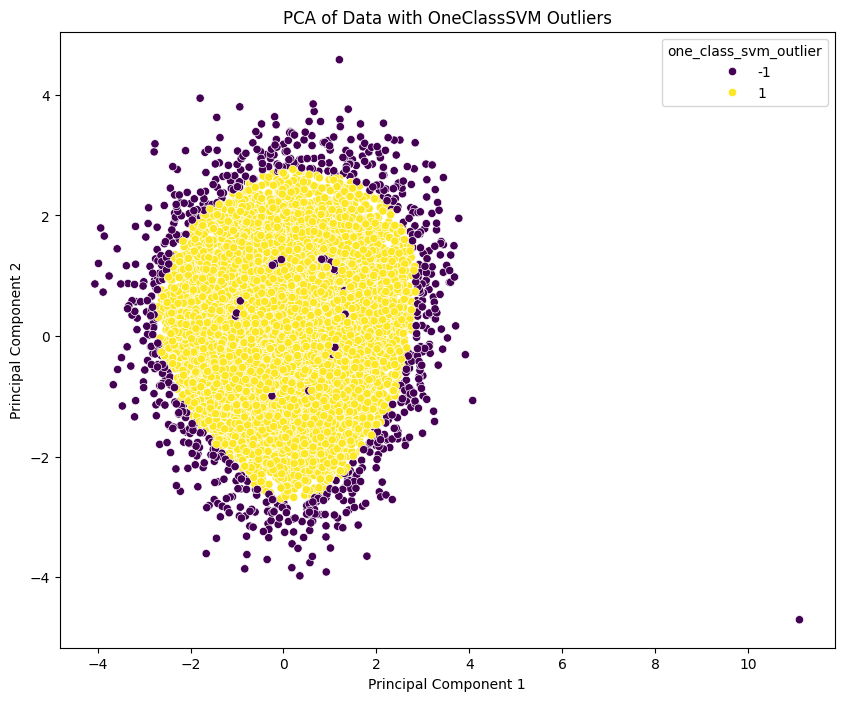

In [ ]:
# Visualise the output in 2D after perfroming PCA, ensure outliers are in a different colour
# create a scatterplot using the one_class_svm_outlier column as colour
plt.figure(figsize=(10, 8))
plt.title('PCA of Data with OneClassSVM Outliers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='one_class_svm_outlier', data=pca_df, palette='viridis', legend='full')

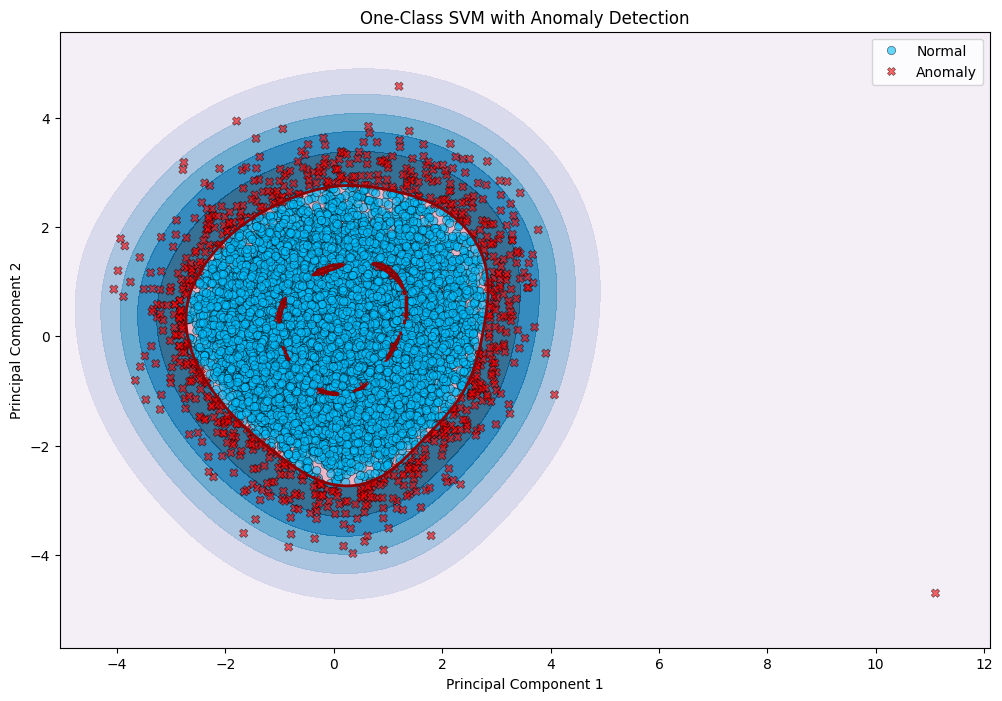

In [ ]:
# Visualise the data in 2D after performing PCA and plot the model

# Visualise the data
def plot_model(model, X_pca, title):
    # Create a grid for plotting decision boundaries and anomaly detection.
    xx, yy = np.meshgrid(np.linspace(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1, 500),
                         np.linspace(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1, 500))

    # Predict whether each point in the meshgrid is an inlier (1) or an outlier (-1).
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Predict whether each point is an inlier (1) or an outlier (-1).
    y_pred = model.predict(X_pca)

    # Plot setup.
    plt.figure(figsize=(12, 8))
    plt.title(title)

    # Plot the decision function levels and decision boundary.
    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap=plt.cm.PuBu, alpha=0.8)
    plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')  # Decision boundary
    plt.contourf(xx, yy, Z, levels=[0, Z.max()], colors='palevioletred', alpha=0.5)  # Anomaly regions

    # Plot also the data points, using different markers for normals and anomalies.
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=np.where(y_pred == 1, 'Normal', 'Anomaly'),
                    style=np.where(y_pred == -1, 'Anomaly', 'Normal'), markers={'Anomaly': 'X', 'Normal': 'o'},
                    palette={'Normal': 'deepskyblue', 'Anomaly': 'red'}, alpha=0.6, edgecolor='k')

    # Plot aesthetics.
    plt.axis('tight')
    # Adjust plot limits based on the PCA transformed data
    plt.xlim((X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1))
    plt.ylim((X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1))
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.show()

# Plot the model
plot_model(model, X_pca, "One-Class SVM with Anomaly Detection")

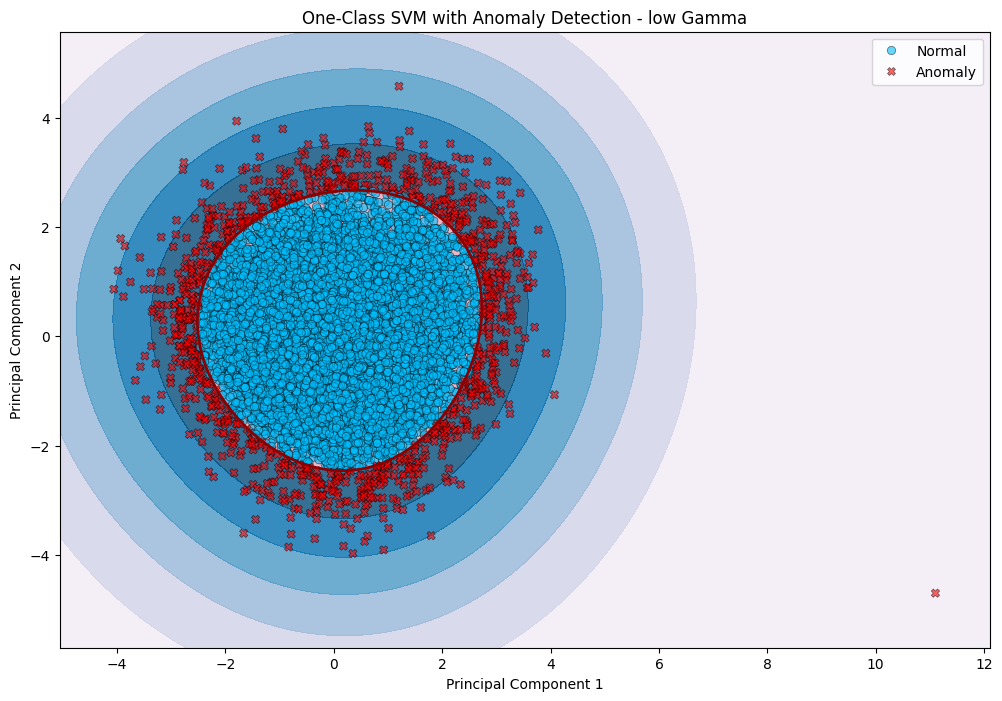

In [ ]:
# Decrease the gamma value
model_low_gamma = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
model_low_gamma.fit(X_pca)
plot_model(model_low_gamma, X_pca, "One-Class SVM with Anomaly Detection - low Gamma")

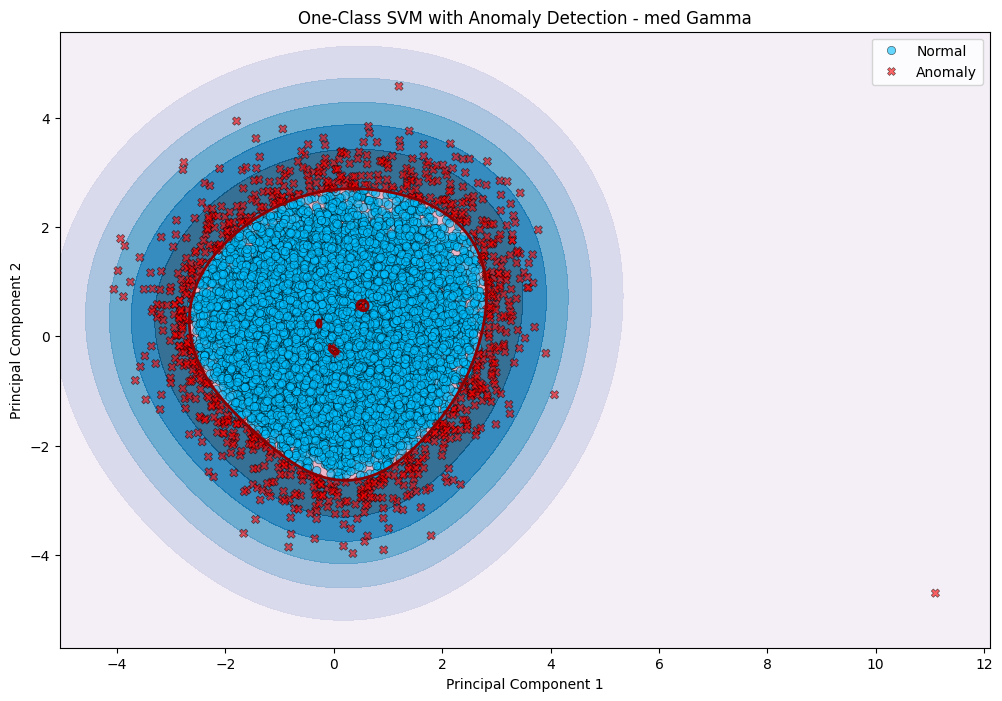

In [ ]:
# Decrease the gamma value
model_med_gamma = OneClassSVM(kernel='rbf', gamma=0.3, nu=0.05)
model_med_gamma.fit(X_pca)
plot_model(model_med_gamma, X_pca, "One-Class SVM with Anomaly Detection - med Gamma")

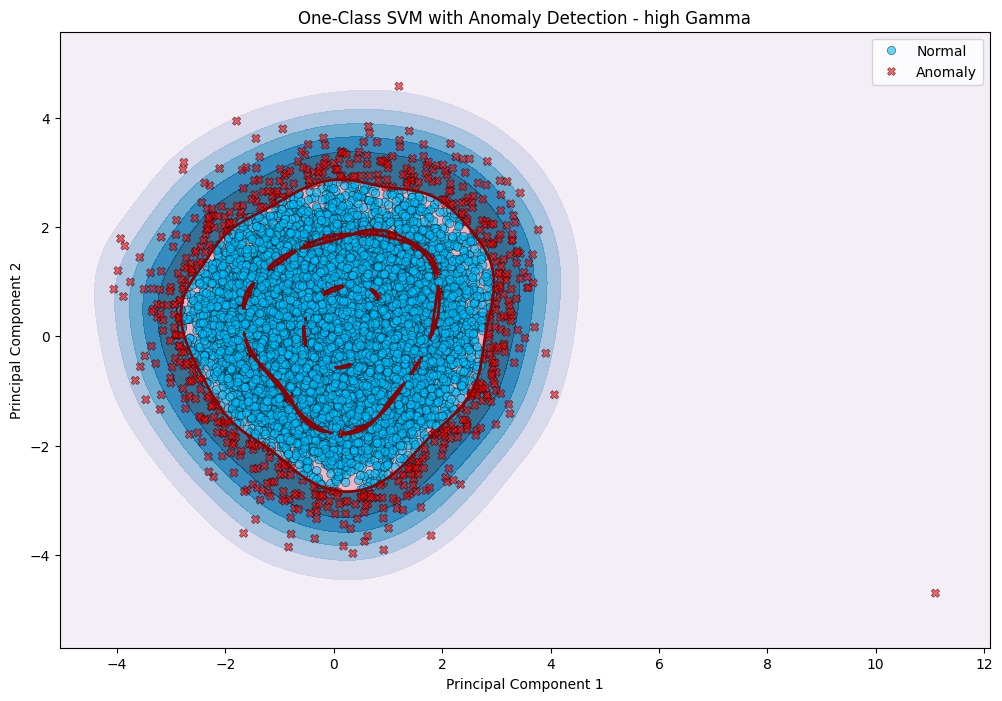

In [ ]:
# Increase the gamma value
model_high_gamma = OneClassSVM(kernel='rbf', gamma=1, nu=0.05)
model_high_gamma.fit(X_pca)
plot_model(model_high_gamma, X_pca, "One-Class SVM with Anomaly Detection - high Gamma")

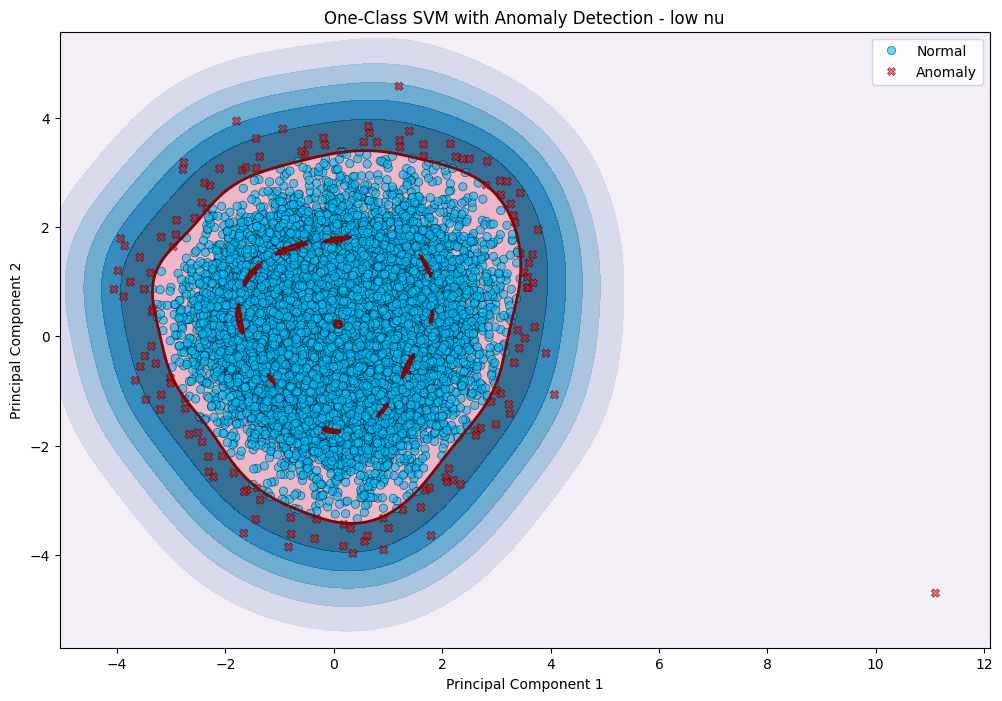

In [ ]:
# Reduce the nu value
model_low_nu = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.01)
model_low_nu.fit(X_pca)
plot_model(model_low_nu, X_pca, "One-Class SVM with Anomaly Detection - low nu")

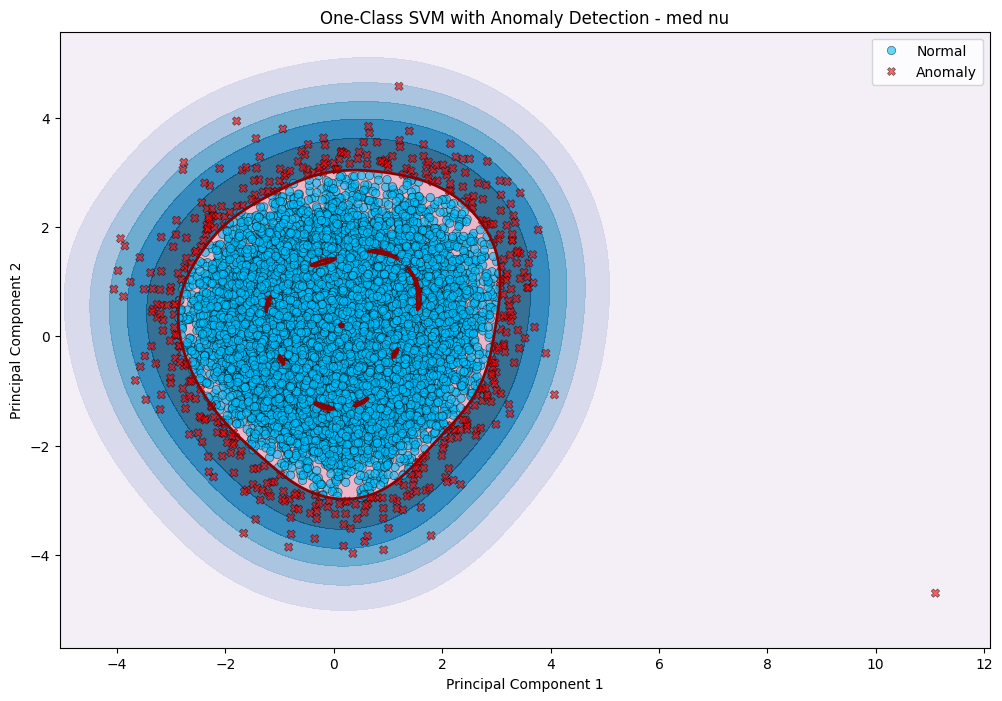

In [ ]:
# Reduce the nu value
model_med_nu = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.03)
model_med_nu.fit(X_pca)
plot_model(model_med_nu, X_pca, "One-Class SVM with Anomaly Detection - med nu")

#Using Isolation forest

In [ ]:
# Initialize and fit Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_forest.fit(df2_engine.select_dtypes(include=np.number))


# Predict anomalies (1 for not anomaly, -1 for anomaly)
y_pred = iso_forest.predict(df2_engine)
# View the output
y_pred


array([ 1, -1, -1, ...,  1,  1,  1])

In [ ]:
# Add anomaly column to the pcadf
pca2_df = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])
pca2_df['isoforest_outlier'] = y_pred
display(pca2_df.head())
pca2_df.shape

,principal_component_1,principal_component_2,isoforest_outlier
0,-0.557362,-0.906512,1
1,-2.177170,-1.201538,-1
2,2.051806,1.039581,-1
3,0.744375,-0.501140,1
4,-1.629821,-0.473906,1


(19535, 3)

In [ ]:
# View only the anomalies
# Display anomalies in the DataFrame.
only_anomalies = pca2_df[pca2_df.isoforest_outlier == -1]

# View output.
print(only_anomalies.shape)
only_anomalies

(1954, 3)


,principal_component_1,principal_component_2,isoforest_outlier
1,-2.177170,-1.201538,-1
2,2.051806,1.039581,-1
7,-2.454301,1.643378,-1
13,1.509749,1.810679,-1
16,2.005457,0.297025,-1
...,...,...,...
19433,-2.149008,-0.649828,-1
19448,-1.645566,1.182693,-1
19451,-0.602201,0.067606,-1
19467,-0.972318,1.248573,-1


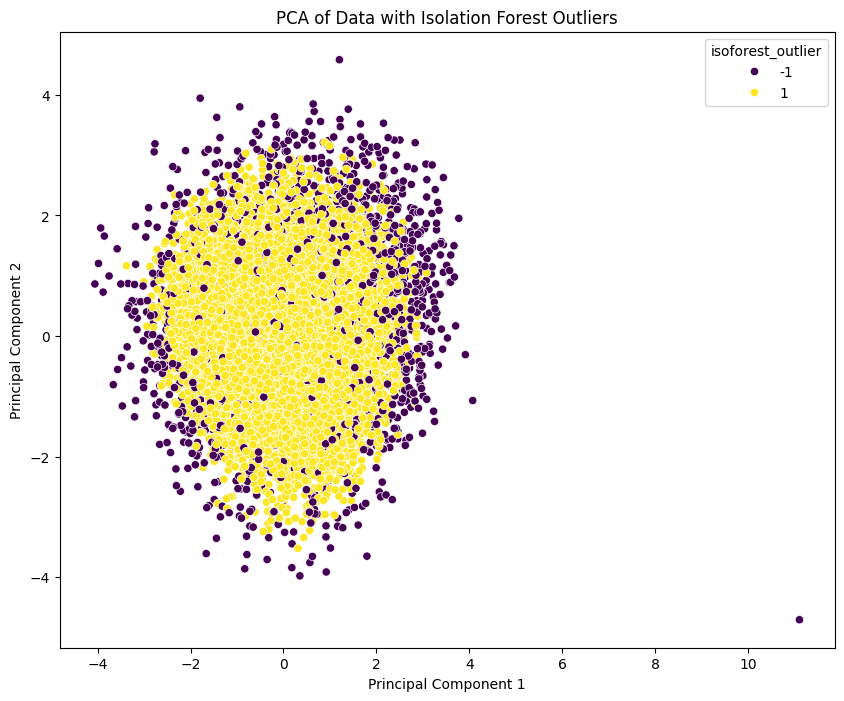

In [ ]:
# visualise the data points using a scatter plot

#create a scatter plot using pca2_df with isoforest_outlier as the colour
plt.figure(figsize=(10, 8))
sns.scatterplot(x='principal_component_1', y='principal_component_2', hue='isoforest_outlier', data=pca2_df, palette='viridis', legend='full')
plt.title('PCA of Data with Isolation Forest Outliers')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [ ]:
# Tune Isolation Forest parameters
# Iterate through different values for the contamination parameter
contamination_values = [0.01, 0.02, 0.03, 0.04, 0.05] # Example contamination values to try

print("Tuning Isolation Forest with different contamination values:")


for contamination in contamination_values:
  # Initialize and fit the Isolation Forest model with the current contamination value
  iso_forest_tuned = IsolationForest(n_estimators=100, contamination=contamination, random_state=42)
  iso_forest_tuned.fit(df2_engine.select_dtypes(include=np.number))

  # Predict anomalies
  iso_forest_predictions_tuned = iso_forest_tuned.predict(df2_engine.select_dtypes(include=np.number))

  # Count the number of outliers (-1)
  num_outliers = np.sum(iso_forest_predictions_tuned == -1)
  percentage_outliers = (num_outliers / len(df2_engine)) * 100

  print(f"Contamination = {contamination}: Number of outliers = {num_outliers} ({percentage_outliers:.2f}%)")



Tuning Isolation Forest with different contamination values:
Contamination = 0.01: Number of outliers = 196 (1.00%)
Contamination = 0.02: Number of outliers = 391 (2.00%)
Contamination = 0.03: Number of outliers = 587 (3.00%)
Contamination = 0.04: Number of outliers = 782 (4.00%)
Contamination = 0.05: Number of outliers = 977 (5.00%)


# Reflect

The approach for this project was to carry out exploratory data analysis to understand the data and identify the presence of outliers within the data, Visualisation plots were carried out before using statistical and machine learning methods to identify the outliers/anomalies within the dataset.

Three different methods were used for anomaly detection, the Interquartile Range (IQR), One-class SVM and Isolation Forest methods.

Using IQR method, with the business knowledge that records with 2 or more features as outliers will represent anomalies, shows 422 records as anomalous.

The One-Class SVM and Isolation forest methods show 978 and 977 records as being anomalous, which is within the expected 5% of the data.

Visualising the data using pca plots shows the normal data and outliers.

All three methods are usefuland can be used to identify anomalous behaviour of the ships engine.

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]